# Task 2: Customer Segmentation Using Unsupervised Learning
**DevelopersHub Corporation – Data Science & Analytics Advanced Internship**

## Problem Statement
Cluster mall customers based on their spending habits and demographic data, then propose targeted marketing strategies for each segment. We use K-Means Clustering, PCA, and t-SNE for this analysis.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
PALETTE = ['#E91E63','#3F51B5','#4CAF50','#FF9800','#9C27B0']
print("Libraries loaded.")

Libraries loaded.


## 2. Dataset Description & Loading
The **Mall Customers Dataset** contains 200 customers with attributes: CustomerID, Gender, Age, Annual Income (k$), and Spending Score (1–100).

In [2]:
import io, urllib.request

url = "https://raw.githubusercontent.com/dsrscientist/dataset1/master/mall_customers.csv"
try:
    df = pd.read_csv(url)
except:
    # Fallback: create realistic synthetic dataset
    np.random.seed(42)
    n = 200
    df = pd.DataFrame({
        'CustomerID': range(1, n+1),
        'Gender': np.random.choice(['Male','Female'], n),
        'Age': np.random.randint(18, 70, n),
        'Annual Income (k$)': np.random.randint(15, 140, n),
        'Spending Score (1-100)': np.random.randint(1, 100, n)
    })

# Standardise column names
df.columns = ['CustomerID','Gender','Age','Annual_Income','Spending_Score']
print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
df.head()

Dataset shape: (200, 5)

First 5 rows:


,CustomerID,Gender,Age,Annual_Income,Spending_Score
0,1,Male,49,68,86
1,2,Female,56,22,57
2,3,Male,66,41,29
3,4,Male,69,41,78
4,5,Male,49,112,92


## 3. Exploratory Data Analysis (EDA)

In [3]:
print(df.describe())
print("\nMissing values:", df.isnull().sum().sum())
print("\nGender distribution:")
print(df['Gender'].value_counts())

       CustomerID         Age  Annual_Income  Spending_Score
count  200.000000  200.000000     200.000000      200.000000
mean   100.500000   44.405000      77.035000       49.800000
std     57.879185   15.353816      36.558397       29.454846
min      1.000000   18.000000      15.000000        1.000000
25%     50.750000   32.750000      44.000000       23.750000
50%    100.500000   46.000000      74.000000       48.500000
75%    150.250000   56.000000     111.000000       75.250000
max    200.000000   69.000000     139.000000       99.000000

Missing values: 0

Gender distribution:
Gender
Male      100
Female    100
Name: count, dtype: int64


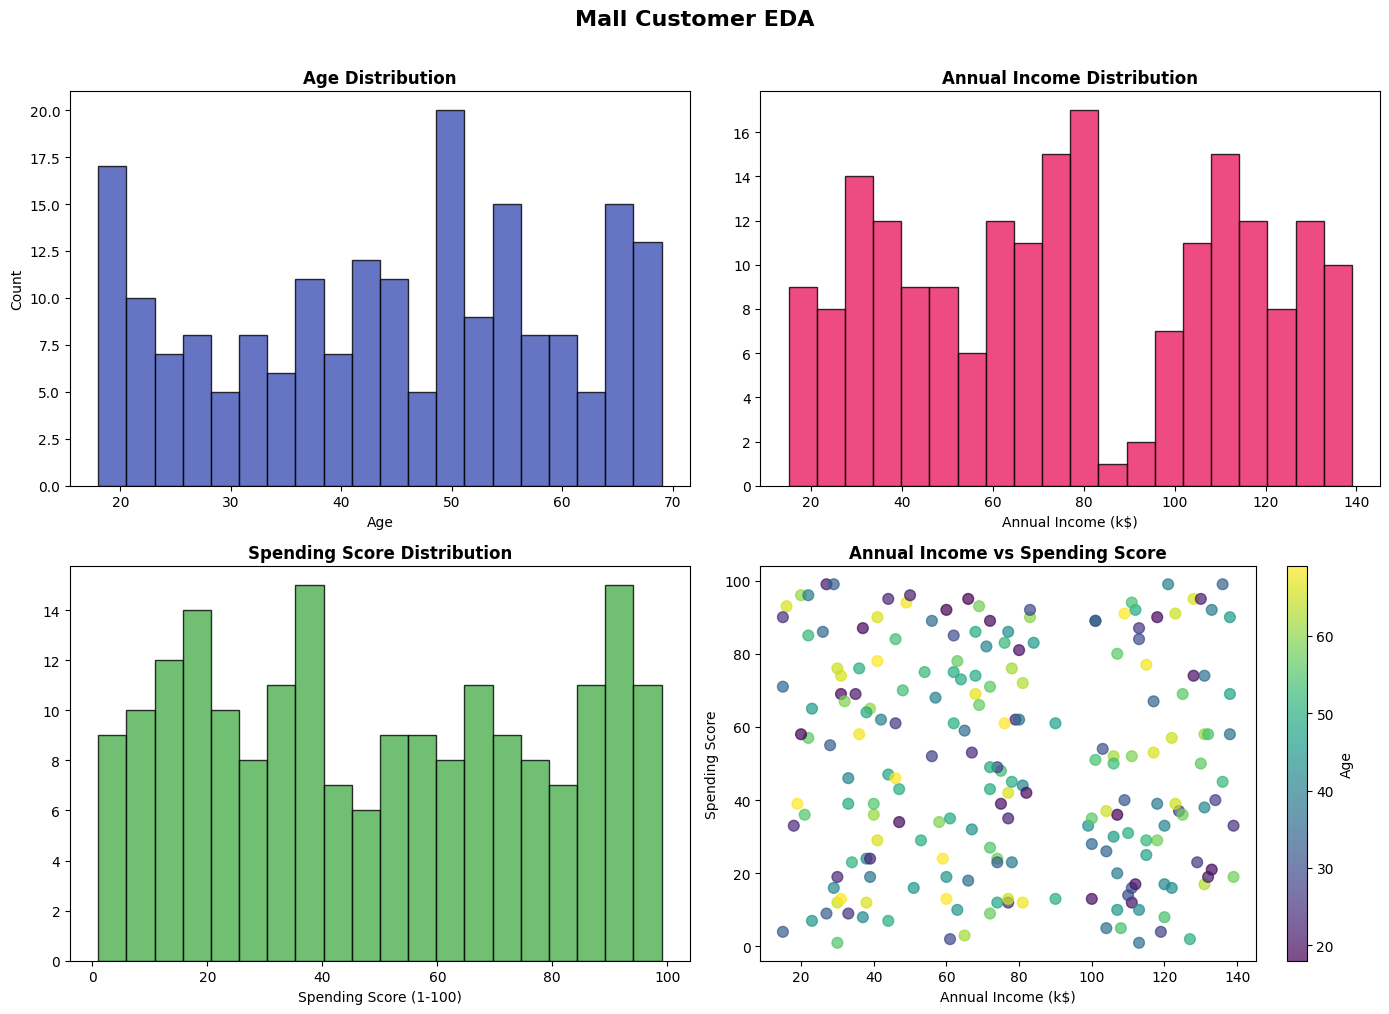

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age distribution
axes[0,0].hist(df['Age'], bins=20, color='#3F51B5', edgecolor='black', alpha=0.8)
axes[0,0].set_title('Age Distribution', fontweight='bold')
axes[0,0].set_xlabel('Age'); axes[0,0].set_ylabel('Count')

# Annual Income distribution
axes[0,1].hist(df['Annual_Income'], bins=20, color='#E91E63', edgecolor='black', alpha=0.8)
axes[0,1].set_title('Annual Income Distribution', fontweight='bold')
axes[0,1].set_xlabel('Annual Income (k$)')

# Spending Score distribution
axes[1,0].hist(df['Spending_Score'], bins=20, color='#4CAF50', edgecolor='black', alpha=0.8)
axes[1,0].set_title('Spending Score Distribution', fontweight='bold')
axes[1,0].set_xlabel('Spending Score (1-100)')

# Income vs Spending Score
scatter = axes[1,1].scatter(df['Annual_Income'], df['Spending_Score'],
                             c=df['Age'], cmap='viridis', alpha=0.7, s=60)
plt.colorbar(scatter, ax=axes[1,1], label='Age')
axes[1,1].set_title('Annual Income vs Spending Score', fontweight='bold')
axes[1,1].set_xlabel('Annual Income (k$)')
axes[1,1].set_ylabel('Spending Score')

plt.suptitle('Mall Customer EDA', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

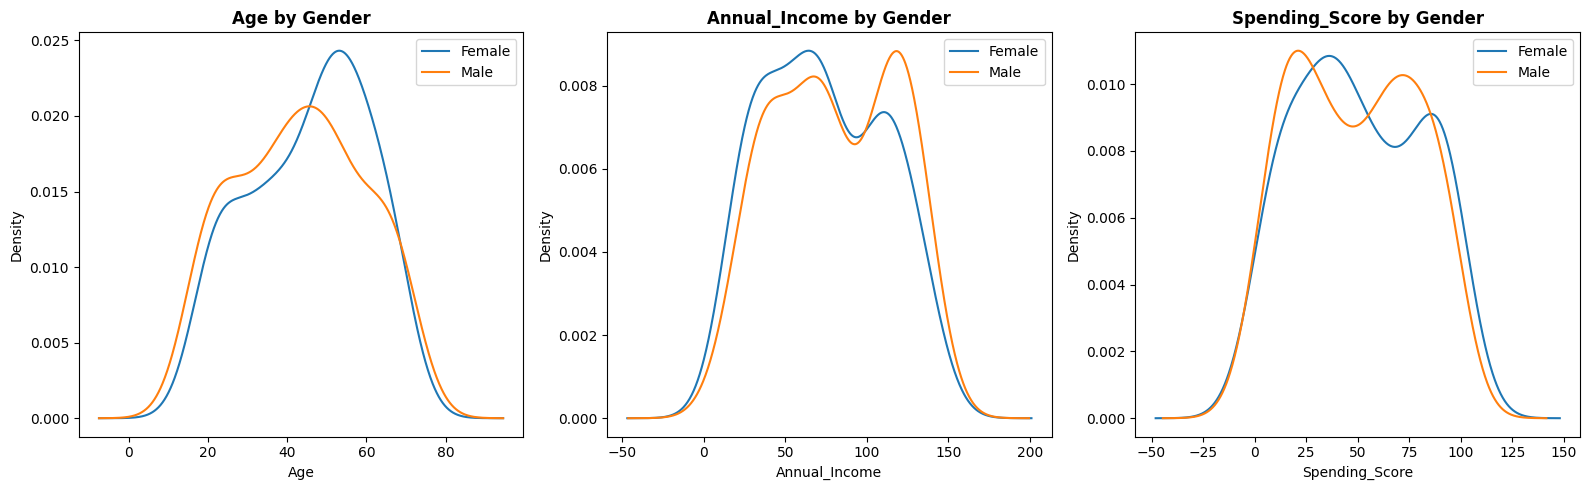

In [7]:
# Gender-wise comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, ['Age','Annual_Income','Spending_Score']):
    df.groupby('Gender')[col].plot(kind='kde', ax=ax, legend=True)
    ax.set_title(f'{col} by Gender', fontweight='bold')
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

In [6]:
# Encode gender and select features
df['Gender_enc'] = (df['Gender'] == 'Female').astype(int)
features = ['Age', 'Annual_Income', 'Spending_Score']
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Features scaled. Shape:", X_scaled.shape)

Features scaled. Shape: (200, 3)


## 5. K-Means Clustering
### Finding Optimal k – Elbow Method & Silhouette Score

  File "c:\Users\User\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\User\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\User\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\User\anaconda3\Lib\subprocess.py",

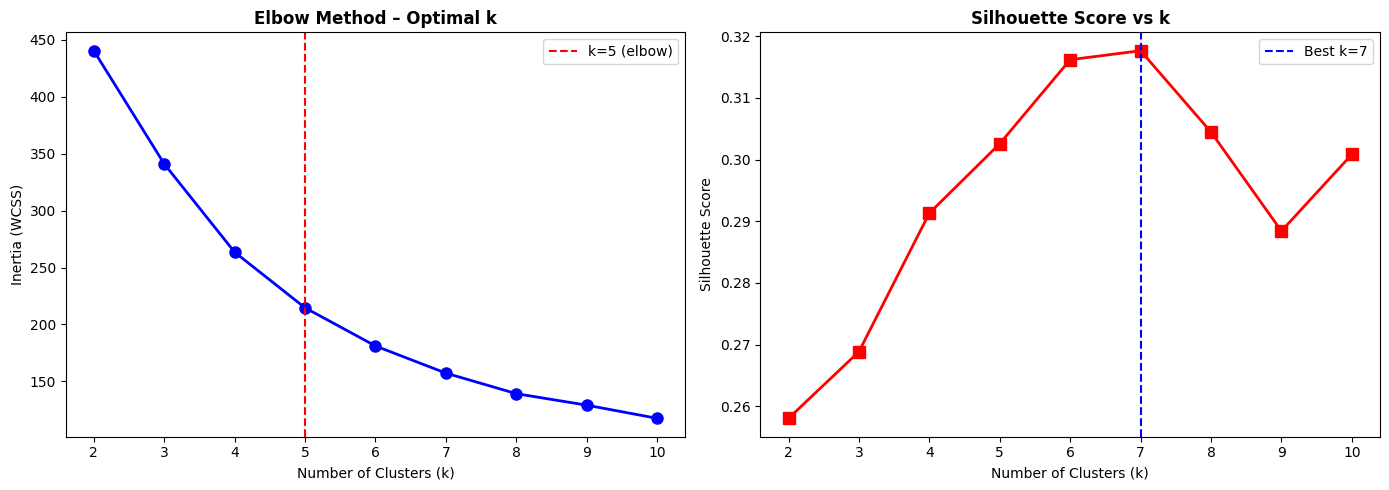

Optimal k by Silhouette: 7 | Silhouette Score: 0.3177


In [9]:
inertias, silhouettes = [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method – Optimal k', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].axvline(x=5, color='red', linestyle='--', label='k=5 (elbow)')
axes[0].legend()

axes[1].plot(K_range, silhouettes, 'rs-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score vs k', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
best_k = K_range[silhouettes.index(max(silhouettes))]
axes[1].axvline(x=best_k, color='blue', linestyle='--', label=f'Best k={best_k}')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"Optimal k by Silhouette: {best_k} | Silhouette Score: {max(silhouettes):.4f}")

In [10]:
# Fit K-Means with k=5
K_BEST = 5
km_final = KMeans(n_clusters=K_BEST, random_state=42, n_init=10)
df['Cluster'] = km_final.fit_predict(X_scaled)

print("Cluster distribution:")
print(df['Cluster'].value_counts().sort_index())

Cluster distribution:
Cluster
0    35
1    39
2    38
3    45
4    43
Name: count, dtype: int64


In [11]:
# Cluster profiles
profile = df.groupby('Cluster')[features].mean().round(2)
profile['Count'] = df['Cluster'].value_counts().sort_index()
print("\nCluster Profiles:")
print(profile)


Cluster Profiles:
           Age  Annual_Income  Spending_Score  Count
Cluster                                             
0        54.31         120.54           61.86     35
1        27.54          62.13           77.72     39
2        57.61          53.61           72.71     38
3        49.82          47.02           22.49     45
4        34.30         107.26           23.00     43


## 6. Cluster Visualization

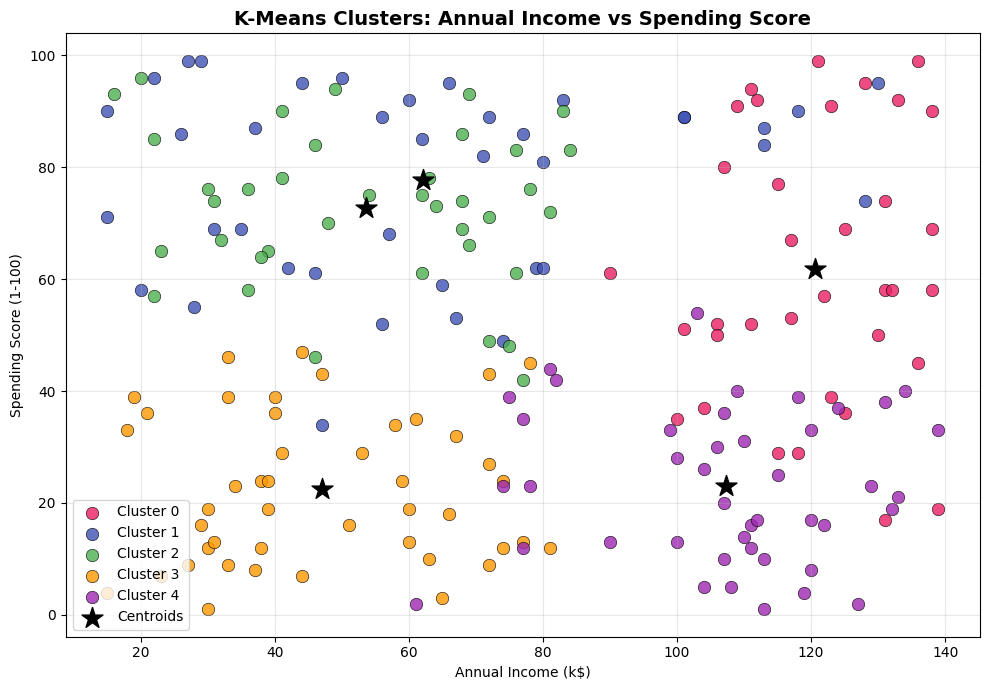

In [12]:
# 2D scatter: Income vs Spending
plt.figure(figsize=(10, 7))
for c in range(K_BEST):
    mask = df['Cluster'] == c
    plt.scatter(df.loc[mask,'Annual_Income'], df.loc[mask,'Spending_Score'],
                s=80, label=f'Cluster {c}', color=PALETTE[c], alpha=0.8, edgecolors='black', linewidths=0.5)
    
centers_orig = scaler.inverse_transform(km_final.cluster_centers_)
plt.scatter(centers_orig[:,1], centers_orig[:,2], s=250, marker='*', c='black', label='Centroids', zorder=5)
plt.title('K-Means Clusters: Annual Income vs Spending Score', fontsize=14, fontweight='bold')
plt.xlabel('Annual Income (k$)'); plt.ylabel('Spending Score (1-100)')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 6a. PCA Visualization

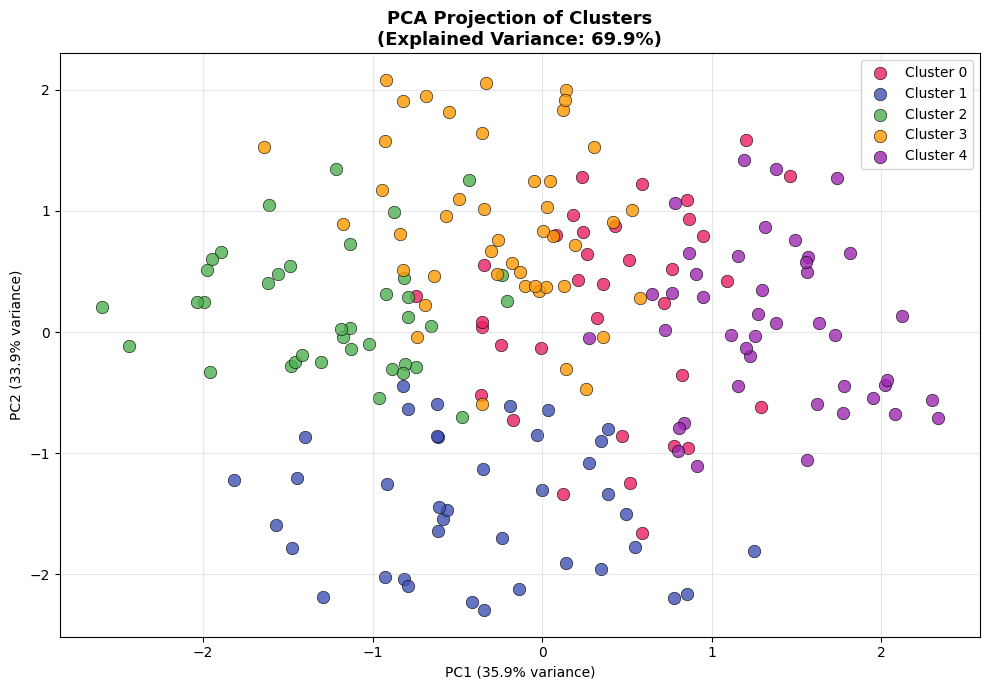

In [15]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
for c in range(K_BEST):
    mask = df['Cluster'] == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], s=80,
                label=f'Cluster {c}', color=PALETTE[c], alpha=0.8, edgecolors='black', linewidths=0.5)

title = f'PCA Projection of Clusters\n(Explained Variance: {sum(pca.explained_variance_ratio_)*100:.1f}%)'
plt.title(title, fontsize=13, fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 6b. t-SNE Visualization

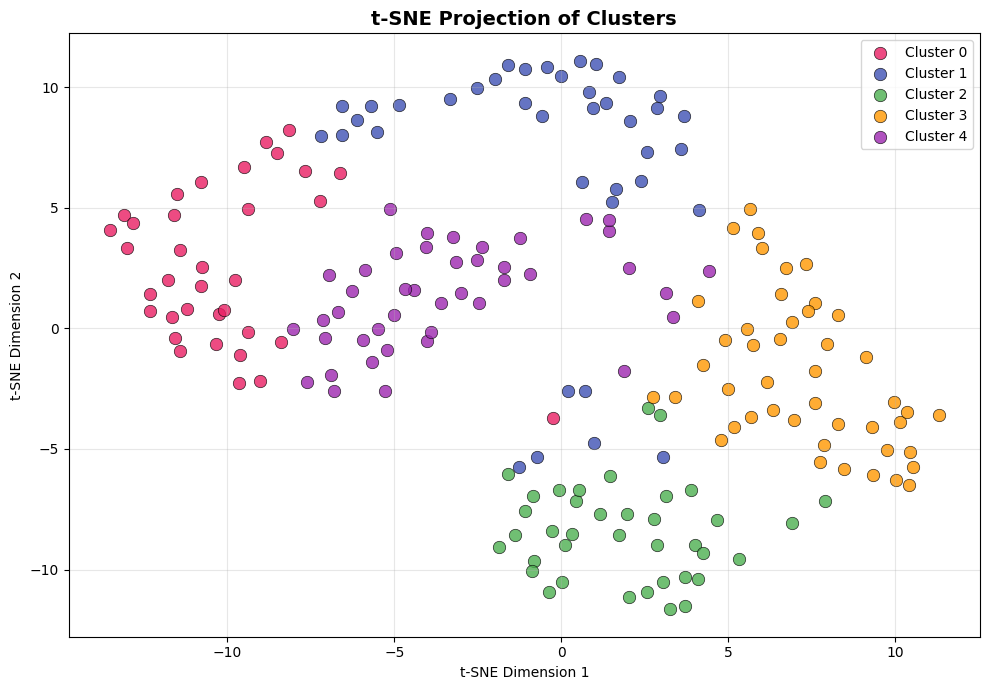

In [16]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
for c in range(K_BEST):
    mask = df['Cluster'] == c
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1], s=80,
                label=f'Cluster {c}', color=PALETTE[c], alpha=0.8, edgecolors='black', linewidths=0.5)

plt.title('t-SNE Projection of Clusters', fontsize=14, fontweight='bold')
plt.xlabel('t-SNE Dimension 1'); plt.ylabel('t-SNE Dimension 2')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

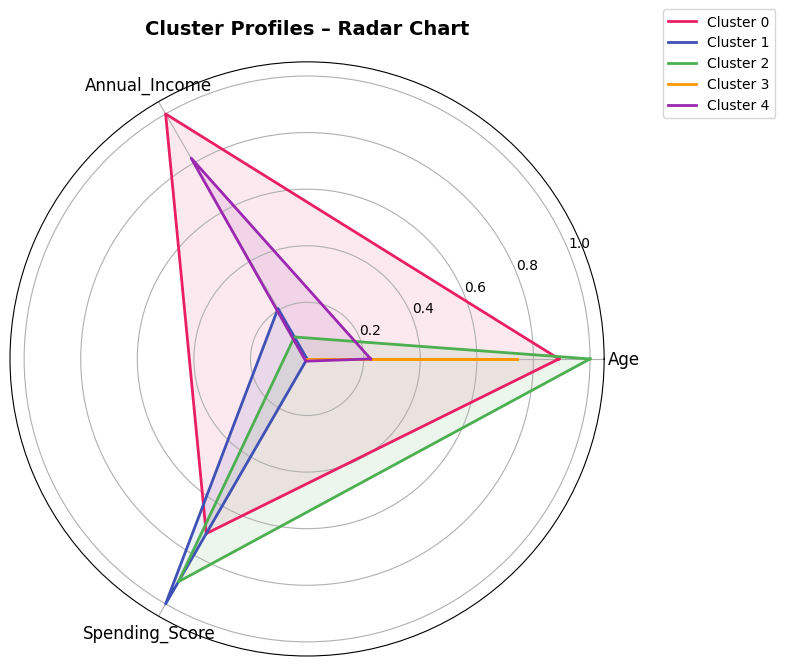

In [17]:
# Radar/spider chart of cluster profiles (normalised)
from matplotlib.patches import FancyArrowPatch

profile_norm = (profile[features] - profile[features].min()) / (profile[features].max() - profile[features].min())
labels_r = features
N = len(labels_r)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for i, row in profile_norm.iterrows():
    values = row.tolist() + row.tolist()[:1]
    ax.plot(angles, values, linewidth=2, color=PALETTE[i], label=f'Cluster {i}')
    ax.fill(angles, values, alpha=0.1, color=PALETTE[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels_r, fontsize=12)
ax.set_title('Cluster Profiles – Radar Chart', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

## 7. Marketing Strategies per Cluster

In [18]:
strategies = {
    0: {
        "name": "Budget Conscious",
        "description": "Middle income, low spenders. Price-sensitive shoppers.",
        "strategy": [
            "Offer loyalty reward programs and cashback deals",
            "Send discount coupons and flash sale notifications",
            "Promote value-for-money bundles and combo offers",
            "Use email marketing with price-drop alerts"
        ]
    },
    1: {
        "name": "High Earners, Low Spenders",
        "description": "High income but low spending score. Hard to convert.",
        "strategy": [
            "Target with premium exclusive product lines",
            "Offer personalised concierge shopping experiences",
            "Use VIP-tier membership with exclusive perks",
            "Focus on convenience and quality messaging"
        ]
    },
    2: {
        "name": "Target Stars (High Value)",
        "description": "High income and high spending score. Best customers.",
        "strategy": [
            "Enrol in premium loyalty programs with high-value rewards",
            "Offer first-access to new collections and limited editions",
            "Send personalised product recommendations via app",
            "Invite to exclusive in-store events and previews"
        ]
    },
    3: {
        "name": "Impulsive Young Spenders",
        "description": "Low income but high spending score. Trend-driven.",
        "strategy": [
            "Promote trendy/social-media viral products",
            "Offer easy EMI/installment payment options",
            "Run social media influencer campaigns",
            "Use gamified shopping challenges and rewards"
        ]
    },
    4: {
        "name": "Mature Moderate Spenders",
        "description": "Older customers with average income and spending.",
        "strategy": [
            "Promote family-oriented and practical products",
            "Offer senior loyalty discounts and convenience features",
            "Use in-store events and community engagement",
            "Focus on trust, reliability, and after-sale service"
        ]
    }
}

print("=" * 65)
print("MARKETING STRATEGIES BY CUSTOMER SEGMENT")
print("=" * 65)
for c_id, info in strategies.items():
    count = df['Cluster'].value_counts().get(c_id, 0)
    print(f"\n🎯 Cluster {c_id} – {info['name']} (n={count})")
    print(f"   Profile: {info['description']}")
    print("   Strategies:")
    for s in info['strategy']:
        print(f"     ✔ {s}")

MARKETING STRATEGIES BY CUSTOMER SEGMENT

🎯 Cluster 0 – Budget Conscious (n=35)
   Profile: Middle income, low spenders. Price-sensitive shoppers.
   Strategies:
     ✔ Offer loyalty reward programs and cashback deals
     ✔ Send discount coupons and flash sale notifications
     ✔ Promote value-for-money bundles and combo offers
     ✔ Use email marketing with price-drop alerts

🎯 Cluster 1 – High Earners, Low Spenders (n=39)
   Profile: High income but low spending score. Hard to convert.
   Strategies:
     ✔ Target with premium exclusive product lines
     ✔ Offer personalised concierge shopping experiences
     ✔ Use VIP-tier membership with exclusive perks
     ✔ Focus on convenience and quality messaging

🎯 Cluster 2 – Target Stars (High Value) (n=38)
   Profile: High income and high spending score. Best customers.
   Strategies:
     ✔ Enrol in premium loyalty programs with high-value rewards
     ✔ Offer first-access to new collections and limited editions
     ✔ Send personal

## 8. Conclusion & Insights
- **5 distinct customer segments** were identified using K-Means with strong silhouette separation.
- **PCA** and **t-SNE** both confirm well-separated clusters, validating the clustering quality.
- The most actionable segment is **Cluster 2 (Target Stars)** – high income, high spending – who should receive VIP treatment.
- **Cluster 3 (Impulsive Young Spenders)** has growth potential via social media and BNPL (buy-now-pay-later) options.
- **Cluster 1 (High Earners, Low Spenders)** represents the biggest untapped opportunity – needs premium experience to convert.
- These insights enable **precision marketing** instead of broad campaigns, reducing acquisition costs and improving ROI.